# Ch09-2 순환 신경망으로 IMDB 리뷰 분류하기

## IMDB 리뷰 데이터 셋

총 50,000개 샘플 = 훈련 데이터 25,000 + 테스트 데이터 25,000

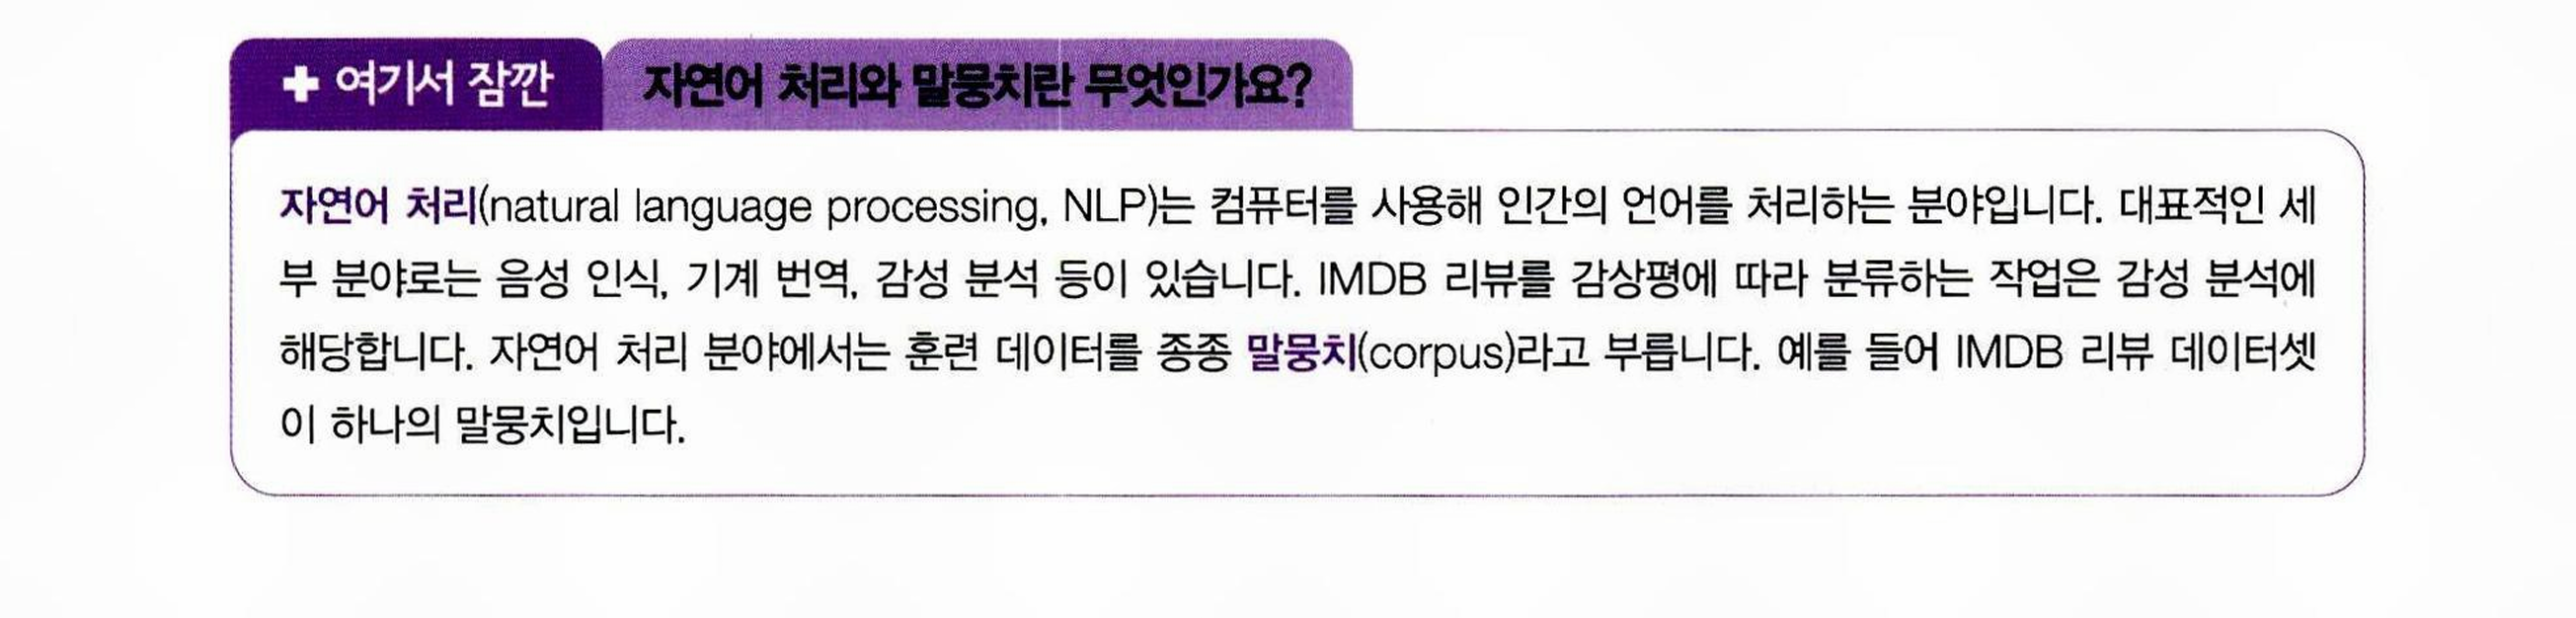

In [1]:
#데이터 자주 사용하는 단어 200개 가져오기
from keras.datasets import imdb

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=200)

2025-12-02 10:39:43.903007: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 10:39:43.921823: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764639583.944700   21612 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764639583.952306   21612 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-02 10:39:43.983288: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 69664113be75683a8fe16e3ed0ab59fda8886cb3cd7ada244f7d9544e4676b9f so we will re-download the data.
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
#훈련 세트와 테스트 세트의 크기 확인
print(train_input.shape, test_input.shape)

(25000,) (25000,)


IMDB 리뷰 텍스트는 길이가 제각각이므로 고정 크기의 2차원 배열보다는 리뷰마다 별도의 파이썬 리스트로 담아 메모리를 효율적으로 사용.      
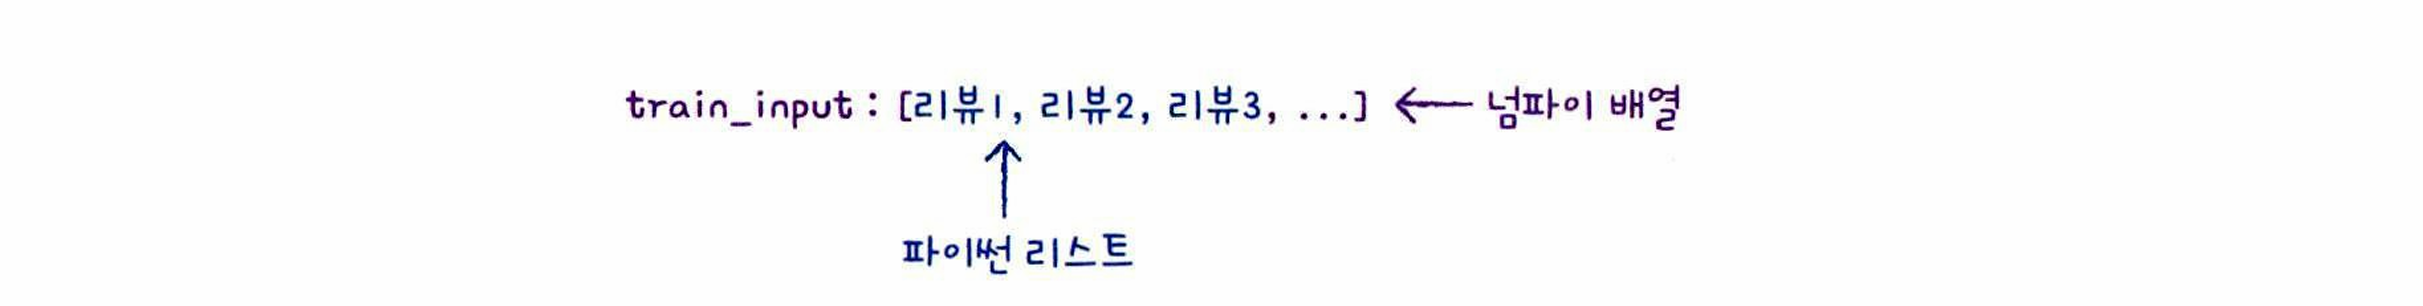

넘파이는 정수나 실수가 아닌 다른 파이썬 객체를 담을 수 있음

In [ ]:
#첫 번째 리뷰의 길이
print(len(train_input[0]))
#218개의 토큰

218


In [ ]:
#두 번째 리뷰의 길이
print(len(train_input[1]))
#189개의 토큰

189


In [5]:
#첫 번째 리뷰에 담긴 내용 출력
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


처음에 어휘 사전 200개를 가져왔고, 200개 안에 없는 단어는 모두 2로 표시     

In [6]:
#타킷 데이터를 출력
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


타깃값 0 (부정) 1 (긍정)

In [7]:
#훈련세트에서 검증세트 나누기 (20%)
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [9]:
#각 리뷰의 길이를 계산해 넘파이 배열에 담기 
# 평균 리뷰 길이와 가장 짧/긴 길이를 확인해보기

import numpy as np
lengths = np.array([len(x) for x in train_input])

In [ ]:
print(np.mean(lengths), np.median(lengths))
#리뷰의 평균 단어 수 239개, 중간값 178개 

239.00925 178.0


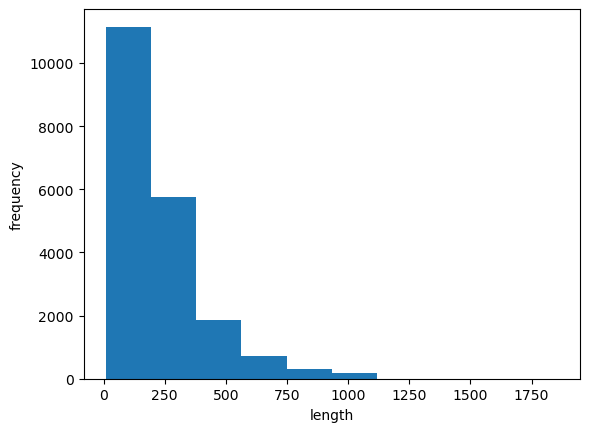

In [11]:
#히스토그램
import matplotlib.pyplot as plt     

plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

한쪽으로 치우쳐 있음.       
대부분 리뷰의 길이는 300미만        


In [ ]:
# 훈련세트의 리뷰를 순회하면서 길이가 100이 되도록 자르거나 0으로 패딩 채우기
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)

In [14]:
#train_seq 크기 확인
print(train_seq.shape)


(20000, 100)


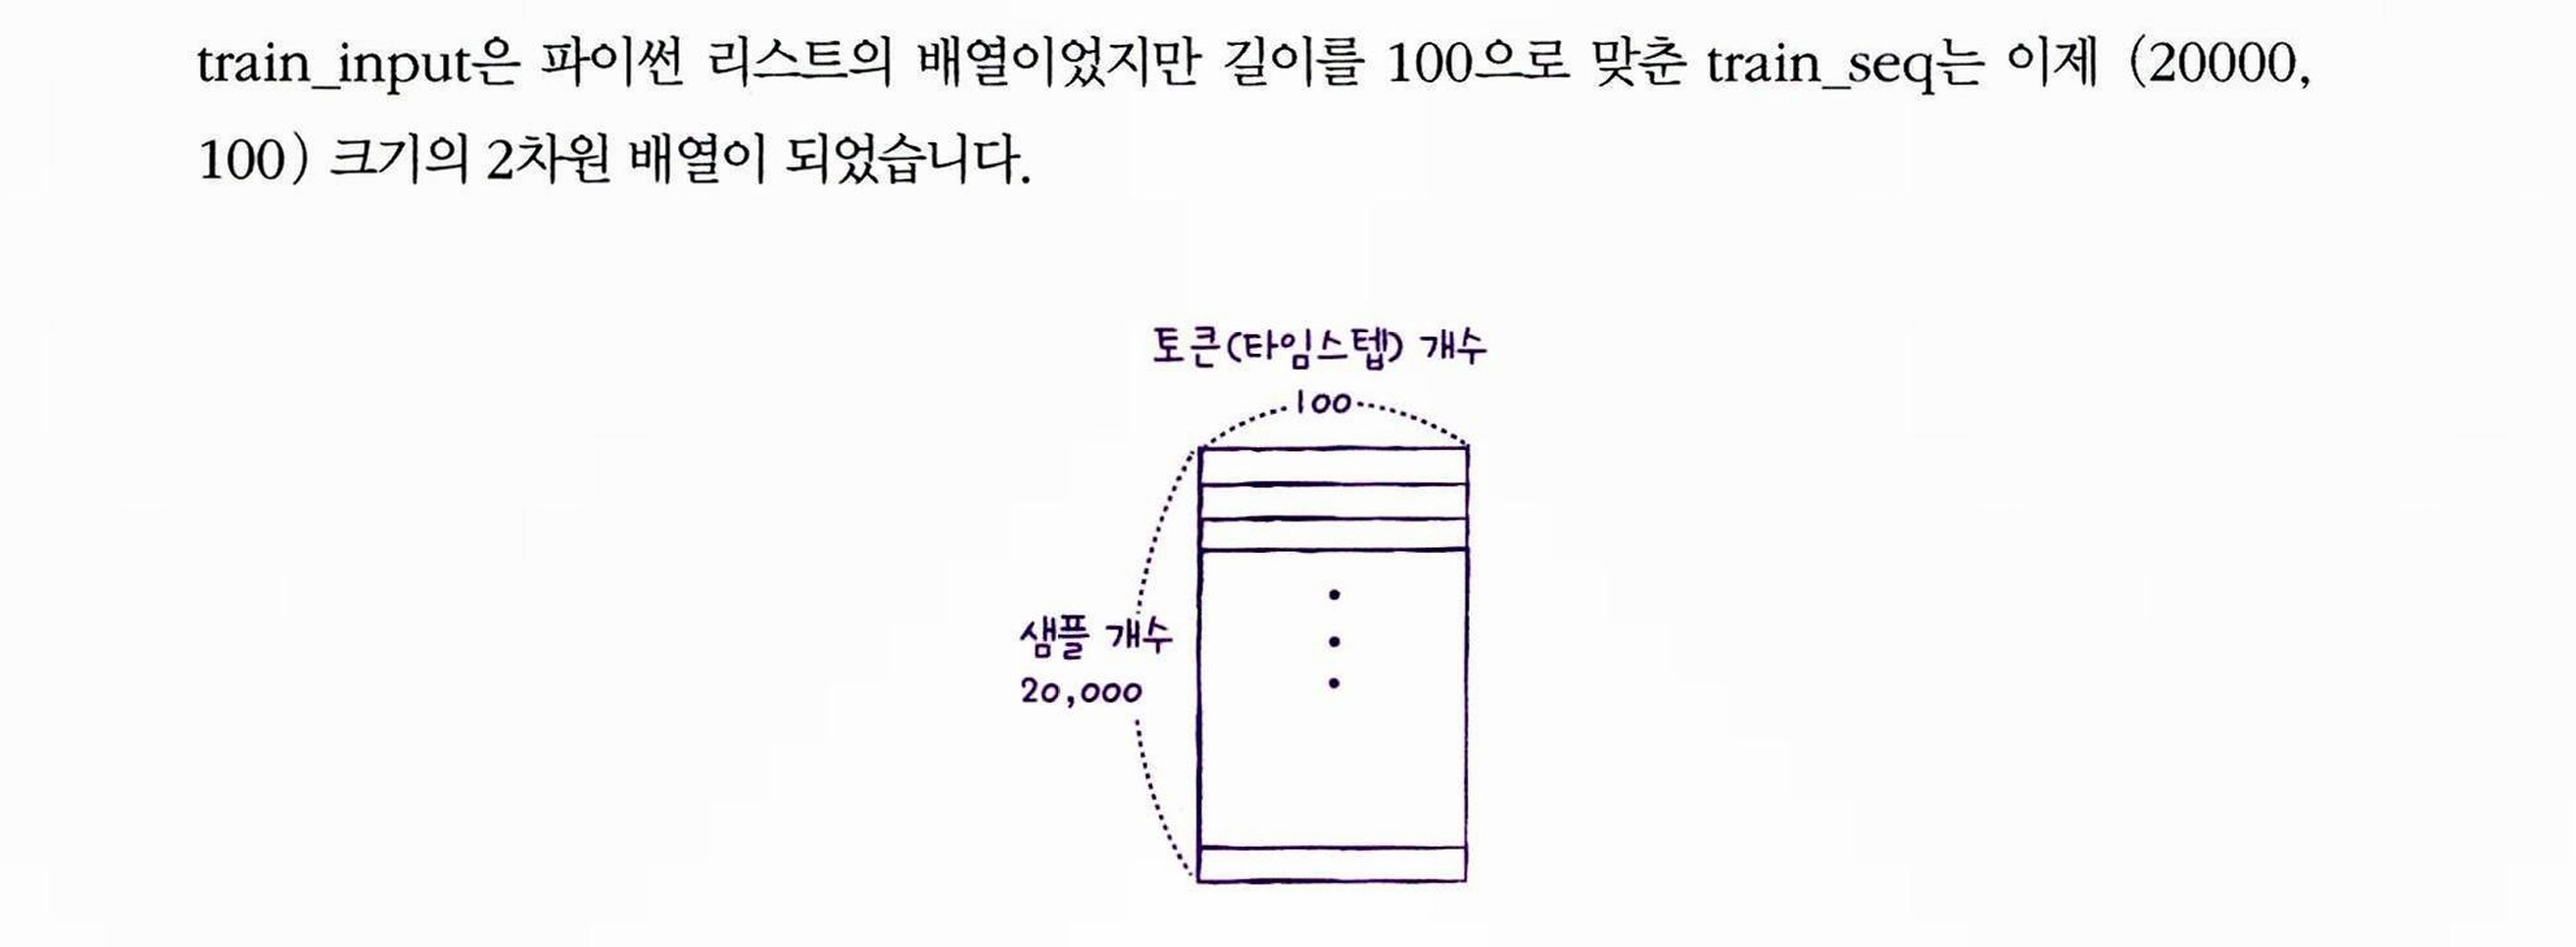

In [15]:
#train_seq에 있는 첫 번째 샘플 출력
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


패딩이 없으므로 100 보다 긴 글이었떤 것 같음

In [16]:
#샘플의 끝 확인
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


일치하는 것을 보아 샘플의 앞부분이 잘렸다는 것을 짐작할 수 있음         
`pad_sequence` 함수는 기본으로 maxlen보다 긴 시퀀스의 앞부분을 자른다.  
일반적으로 시퀀스의 뒷부분 정보가 더 유용하다고 생각하기 때문.      

만약, 앞부분을 남기고, 뒷 부분을 자르고 싶다면 truncating 매개변수의 값을 기본값인 'pre'가 아닌 'post'로 바꾸면 된다.       

In [17]:
#여섯번째 샘플 출력
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


패딩 역시 앞부분에 추가됨

In [18]:
#검증세트의 길이도 100으로 맞추어 보기
val_seq = pad_sequences(val_input, maxlen=100)

## 2. 순환 신경망 만들기    

케라스의 여러종류의 순환층 클래스를 제공
`SimpleRNN`클래스 

In [19]:
import keras
model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,200)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

I0000 00:00:1764642211.961838   21612 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


그러나, 토큰을 정수로 변환한 이 데이터를 신경망에 주입하면 큰 정수가 큰 활성화출력을 만들게 됨.     
그러나 정수에는 의미 차이나 크기 차이가 없으므로 다른 방식을 찾아야 함      

정숫값에 있는 크기 속성을 없애고 각 정수를 고유하게 표현하는 방법으로
**'원-핫 인코딩'**을 이용함     
- 정숫값을 배열에서 해당 정수 위치의 원소만 1로 ,나머지는 모두 0으로 변환       
- train_seq[0]의 첫 번째 토큰인 10을 원-핫 인코딩으로 바꾸면? -> 열한번째 원소만 1이고 나머지는 다 0이 됨   
- 또, 200개 단어만 사용하도록 지정했으므로 0은 199개

keras에는 원-핫 인코딩을 위한 유틸리티를 제공. 수동으로 배열을 만들 필요 없음           
`keras.utils` 패키지의 `to_categorical()`함수

In [ ]:
#train_seq를 원핫인코딩으로 변환하여 train_oh 배열 만들기
train_oh = keras.utils.to_categorical(train_seq)


In [21]:
#배열 크기 확인
print(train_oh.shape)

(20000, 100, 200)


In [22]:
#첫번째 토큰 
print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [23]:
#다 더해서 1이 되는지 확인
print(np.sum(train_oh[0][0]))

1.0


In [24]:
#val_oh도 변경하기
val_oh = keras.utils.to_categorical(val_seq)

In [25]:
#모델 구조 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

## 3. 순환 신경망 훈련하기 

In [27]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=16, validation_data=(val_oh, val_target),
                                                        callbacks=[checkpoint_cb, early_stopping_cb])

2025-12-02 12:09:10.008254: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.49GiB (rounded to 1600000000)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-12-02 12:09:10.008471: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1053] BFCAllocator dump for GPU_0_bfc
2025-12-02 12:09:10.008519: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1060] Bin (256): 	Total Chunks: 420, Chunks in use: 420. 105.0KiB allocated for chunks. 105.0KiB in use in bin. 2.6KiB client-requested in use in bin.
2025-12-02 12:09:10.008532: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1060] Bin (512): 	Total Chunks: 0, Chunks in use: 0. 0B allocated for chunks. 0B in use in bin. 0B client-requested in use in bin.
2025-12-02 12:0

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

4gb gpu로는 실행 불가.

## 4. 단어 임베딩을 사용하기

순환 신경망에서 텍스트를 처리할 때 자주 쓰는 방법이 **단어 임베딩_word embedding** 


단어 임베딩은 각 단어를 고정된 크기의 실수 벡터로 바꾸어 준다.  
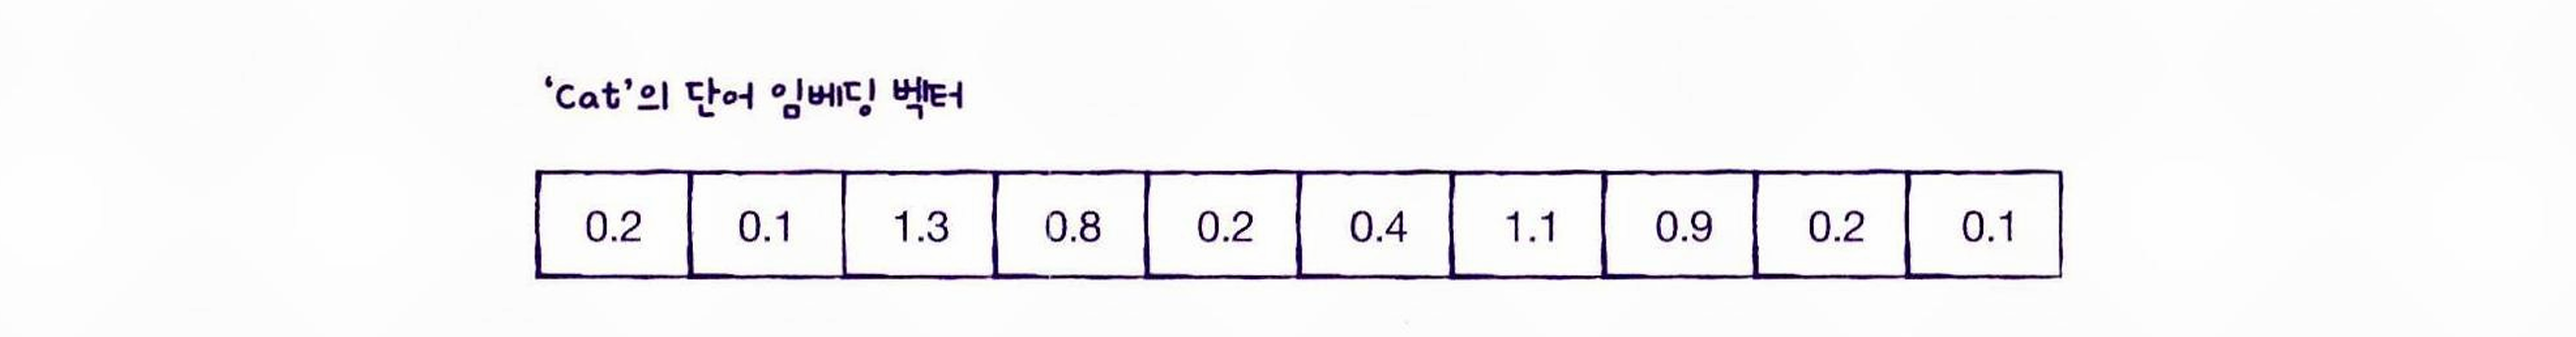

`keras.layers` 패키지 아래 `Embedding` 클래스       
train_oh 로변환한 배열이 아니라 train_seq를 사용할 수 있음.

In [28]:
#많이 쓰는 단어 500개 선택하여 다시 데이터 셋 준비
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [30]:
#simplernn 층 앞에 추가해 두번째 순환 신경망 만들기

model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500,16))
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

In [31]:
model_emb.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

Embedding 클래스는 200개의 각 토큰을 크기가 16인 벡터로 변경.   
모델 파라미터 = 200 x 16 = 3,200        

SimpleRNN층은 임베딩 벡터의 크기가 16이므로 8개의 뉴런과 곱하기 위해 필요한 가중치
16 x 8 = 128 개     

은닉 가중치   8 x 8 =16개       

절편 8개        

총 파라미터 개수 = 128 + 64 + 8 = 200개 


마지막 Dense 층의 가중치 개수는 이전과 동일하개 9개         
- 원핫인코딩보다 simplernn에 주입되는 입력의 크기가 줄었지만, 임베딩 벡터는 단어를 잘 표현하는 능력이 있기 때문에 결과는 유사할 것. 

In [32]:
# 모델 훈련
model_emb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target),
                                                        callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.5798 - loss: 0.6675 - val_accuracy: 0.7312 - val_loss: 0.5467
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7540 - loss: 0.5176 - val_accuracy: 0.7672 - val_loss: 0.4941
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7835 - loss: 0.4747 - val_accuracy: 0.7572 - val_loss: 0.5083
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.7929 - loss: 0.4576 - val_accuracy: 0.7676 - val_loss: 0.4903
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.7915 - loss: 0.4566 - val_accuracy: 0.7826 - val_loss: 0.4745
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8067 - loss: 0.4332 - val_accuracy: 0.7752 - val_loss: 0.4828
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.8029 - loss: 0.4336 - val_accuracy: 0.7872 - val_loss: 0.4688
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8206 - loss: 0

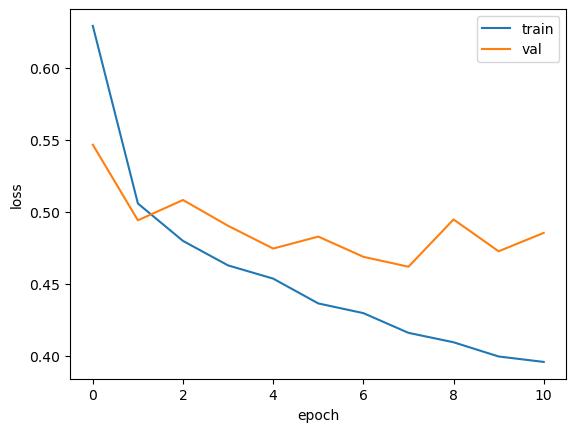

In [34]:
#훈련 손실과 검증 손실을 그래프로 출력
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

`pad_sequences()` 시퀀스 길이를 맞추기 위해 패딩 추가   
- `maxlen` 매개변수로 원하는 시퀀스 길이 지정 가능  
- `padding` 매개변수는 패딩을 추가할 위치 지정 : 기본 (pre) 은 앞에 패딩 추가/ (post) 는 뒤에 패딩 추가         
- `truncating` 매개변수는 긴 시퀀스에서 잘라버릴 위치를 지정 : 기본(pre)는 시퀀스 앞부분을 자름 /(post)는 뒷부분을 자름     

`to_categorical()` 은 정수 시퀀스를 원-핫 인코딩으로 변환   

`SimpleRNN`은 케라스의 기본 순환층 클래스   
- 첫 번째 매개변수에 뉴런 개수 지정     
- `activation` 매개변수에서 활성화 함수 지정 : 기본 (tanh)        
- `dropout` 매개변수에서 입력에 대한 드롭아웃 비율 지정 가능        
- `return_sequences` 매개변수에서 모든 타임스텝의 은닉 상태를 출력할지 결정 : 기본 false        

`Embedding`은 단어 임베딩을 위한 클래스         
- 첫 번째 매개변수에서 어휘 사전의 크기 지정        
- 두 번째 매개변수에서 출력할 밀집 벡터의 크기 지정     